Loading data...
Rows without regioncode: 0
Calculating district-level SNMI...
Calculating ACZ-level trajectories...
Preparing boxplot data...
Creating Figure 3...


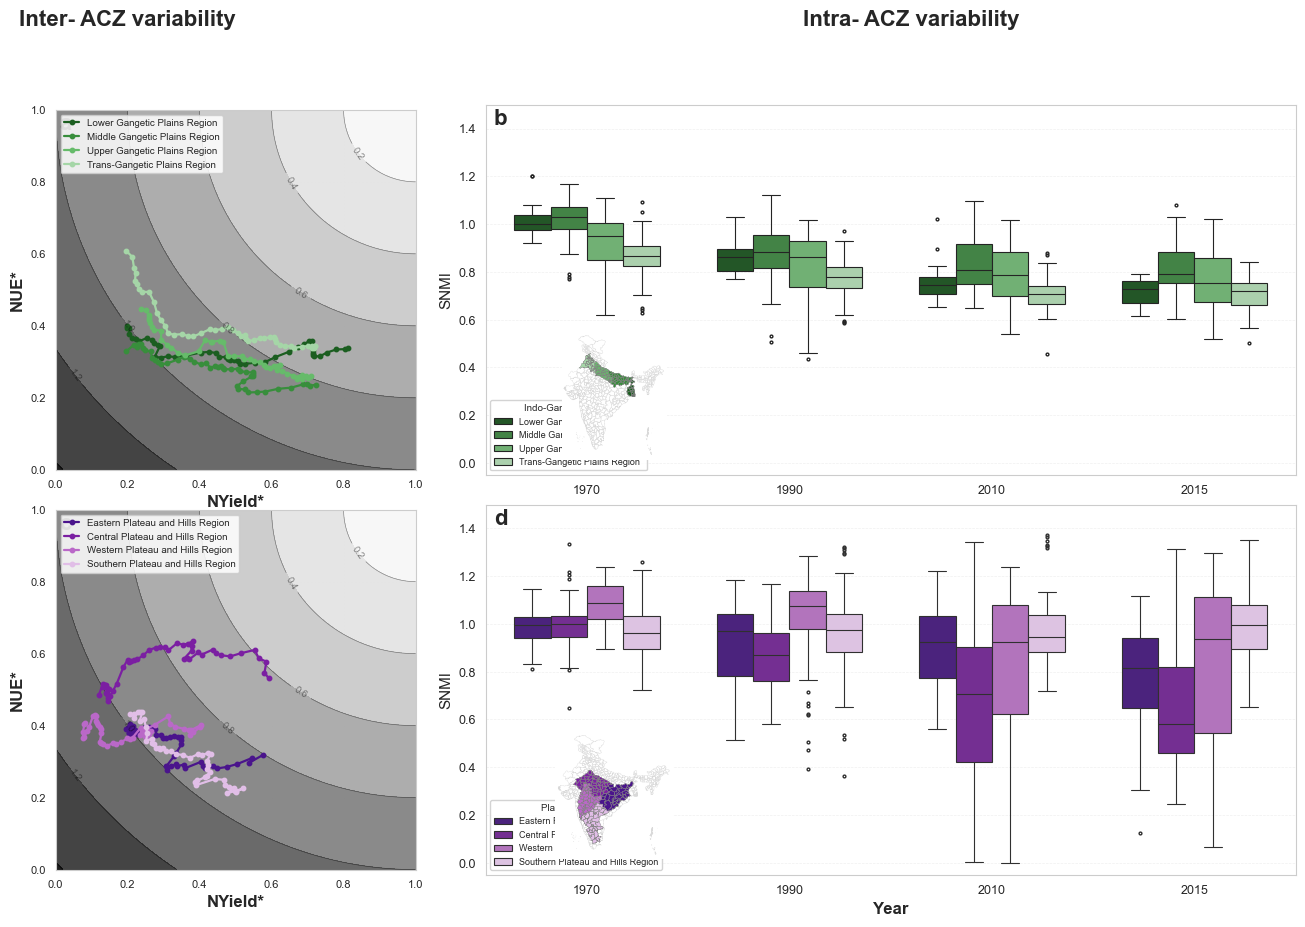

Saved figure: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig_3\Figure3_ACZ_SNMI_variability.png
Saved district SNMI data: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig_3\Figure3_district_SNMI_data.csv
Saved ACZ trajectory data: C:\collaboration\2025\rohini\SNMI\snmi work\data\fig_3\Figure3_ACZ_smoothed_SNMI_data.csv
Done.


In [9]:
# -*- coding: utf-8 -*-
"""
Figure 3: Inter- and intra-agroclimatic-zone variability in SNMI

Panels:
a,c = ACZ trajectories in NYield*–NUE* space
b,d = District-level SNMI variability across periods

Author: Shekhar Goyal
"""

# ============================================================
# 0. IMPORTS
# ============================================================

import os
import string
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")


# ============================================================
# 1. USER SETTINGS
# ============================================================

NSURPLUS_CSV = r"Y:\Home\goyal\latest_backup_lab_pc\shekhar\climate  extreames\hypothetical_yield\nsurplus_district_comp.csv"

DISTRICT_SHP = r"Y:\Home\goyal\latest_backup_lab_pc\shekhar\climate  extreames\district_shape_1966_clim_zone\india_1966_clim_zone.shp"

SAVE_DIR = r"C:\collaboration\2025\rohini\SNMI\snmi work\data\fig_3"
os.makedirs(SAVE_DIR, exist_ok=True)

OUT_FIG = os.path.join(SAVE_DIR, "Figure3_ACZ_SNMI_variability.png")
OUT_DATA_DISTRICT = os.path.join(SAVE_DIR, "Figure3_district_SNMI_data.csv")
OUT_DATA_ACZ = os.path.join(SAVE_DIR, "Figure3_ACZ_smoothed_SNMI_data.csv")

DPI = 600


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def clean_name(x):
    if pd.isna(x):
        return np.nan
    return (
        str(x).strip().lower()
        .replace("&", "and")
        .replace(".", "")
        .replace(",", "")
        .replace("  ", " ")
    )


def get_nue_star(nue):
    """
    For Figure 3, reproduce the original behaviour:
    use NUE directly as NUE* after restricting it to 0–1.
    """
    if pd.isna(nue):
        return np.nan
    if nue < 0 or nue > 1:
        return np.nan
    return nue


def get_nyield_star(nyield, regioncode, nyield_refs):
    ref = nyield_refs.get(regioncode, np.nan)

    if pd.isna(nyield) or pd.isna(ref) or ref == 0:
        return np.nan

    return nyield / ref if nyield <= ref else 1.0


def add_panel_label(ax, label):
    ax.text(
        0.01, 0.99,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=16,
        fontweight="bold"
    )


# ============================================================
# 3. REGION DEFINITIONS
# ============================================================

region_mapping = {
    1: "Western Himalayan Region",
    2: "Eastern Himalayan Region",
    3: "Lower Gangetic Plains Region",
    4: "Middle Gangetic Plains Region",
    5: "Upper Gangetic Plains Region",
    6: "Trans-Gangetic Plains Region",
    7: "Eastern Plateau and Hills Region",
    8: "Central Plateau and Hills Region",
    9: "Western Plateau and Hills Region",
    10: "Southern Plateau and Hills Region",
    11: "East Coast Plains and Hills Region",
    12: "West Coast Plains and Ghat Region",
    13: "Gujarat Plains and Hills Region",
    14: "Western Dry Region",
    15: "The Islands Region"
}

region_groups = {
    "Indo-Gangetic Plains": [3, 4, 5, 6],
    "Plateau Regions": [7, 8, 9, 10]
}

color_palette = {
    3: "#1b5e20",
    4: "#388e3c",
    5: "#66bb6a",
    6: "#a5d6a7",
    7: "#4a148c",
    8: "#7b1fa2",
    9: "#ba68c8",
    10: "#e1bee7"
}

periods = {
    "1970": (1969, 1971),
    "1990": (1989, 1991),
    "2010": (2009, 2011),
    "2015": (2015, 2017)
}


# ============================================================
# 4. LOAD DATA
# ============================================================

print("Loading data...")

n_data = pd.read_csv(NSURPLUS_CSV)
gdf = gpd.read_file(DISTRICT_SHP).to_crs(epsg=4326)

gdf = gdf.rename(columns={
    "State": "State Name",
    "Parent_dis": "Dist Name",
    "District": "Dist Name",
    "DISTRICT": "Dist Name",
    "STATE": "State Name"
})

if "regioncode" not in gdf.columns:
    raise ValueError("Shapefile must contain 'regioncode'.")

if "regionname" not in gdf.columns:
    gdf["regionname"] = gdf["regioncode"].map(region_mapping)

for df in [n_data, gdf]:
    df["state_clean"] = df["State Name"].apply(clean_name)
    df["dist_clean"] = df["Dist Name"].apply(clean_name)

n_data["Year"] = pd.to_numeric(n_data["Year"], errors="coerce")


# ============================================================
# 5. MERGE REGION INFO
# ============================================================

region_lookup = gdf[
    ["state_clean", "dist_clean", "regioncode", "regionname"]
].drop_duplicates()

clim_zone_data = n_data.merge(
    region_lookup,
    on=["state_clean", "dist_clean"],
    how="left"
)

clim_zone_data["regionname"] = clim_zone_data["regioncode"].map(region_mapping)

print("Rows without regioncode:", clim_zone_data["regioncode"].isna().sum())


# ============================================================
# 6. CALCULATE DISTRICT-LEVEL SNMI
# ============================================================

print("Calculating district-level SNMI...")

clim_zone_data["Total_N_input"] = (
    clim_zone_data["Manure_mean"]
    + clim_zone_data["Nitrogen Deposition(kgN)mean"]
    + clim_zone_data["Fertilizer mean"]
    + clim_zone_data["BNF_mean"]
)

clim_zone_data["NYield"] = clim_zone_data[
    ["n_removal_kg_ha", "n_removal_kg_ha_fao"]
].mean(axis=1)

if "NUE_mean" not in clim_zone_data.columns:
    clim_zone_data["NUE_mean"] = (
        clim_zone_data["NYield"] /
        (
            clim_zone_data["Manure_mean"]
            + clim_zone_data["Nitrogen Deposition(kgN/ha)"]
            + clim_zone_data["NITROGEN PER HA OF NCA (Kg per ha)"]
            + clim_zone_data[["BNF_agriculture_KG_per_ha", "BNF_kg_ha_lasestta"]].mean(axis=1)
        )
    )

clim_zone_data.loc[
    (clim_zone_data["NUE_mean"] < 0) | (clim_zone_data["NUE_mean"] > 1),
    "NUE_mean"
] = np.nan

district_max = (
    clim_zone_data
    .groupby(["State Name", "Dist Name"], as_index=False)["NYield"]
    .max()
    .rename(columns={"NYield": "NYield_max"})
)

clim_zone_data = clim_zone_data.merge(
    district_max,
    on=["State Name", "Dist Name"],
    how="left"
)

nyield_refs = (
    clim_zone_data
    .dropna(subset=["regioncode", "NYield_max"])
    .groupby("regioncode")["NYield_max"]
    .quantile(0.90)
    .to_dict()
)

clim_zone_data["NYield_star"] = clim_zone_data.apply(
    lambda row: get_nyield_star(row["NYield"], row["regioncode"], nyield_refs),
    axis=1
)

clim_zone_data["NUE_star"] = clim_zone_data["NUE_mean"].apply(get_nue_star)

clim_zone_data["SNMI"] = np.sqrt(
    (1 - clim_zone_data["NYield_star"]) ** 2
    + (1 - clim_zone_data["NUE_star"]) ** 2
)

clim_zone_data.to_csv(OUT_DATA_DISTRICT, index=False)


# ============================================================
# 7. CALCULATE ACZ-LEVEL TRAJECTORIES
# ============================================================

print("Calculating ACZ-level trajectories...")

ACZ_data = (
    clim_zone_data
    .dropna(subset=["regioncode"])
    .groupby(["Year", "regioncode"])
    .apply(
        lambda g: pd.Series({
            "NUE_climate_zone": g["n_removed_kg_mean"].sum() / g["Total_N_input"].sum(),
            "N_yield_kg_ha_climate_zone": (
                g["n_removed_kg_mean"].sum()
                / (1000 * g["NET CROPPED AREA (1000 ha)"].sum())
            )
        })
    )
    .reset_index()
)

ACZ_data["NYield_star"] = ACZ_data.apply(
    lambda row: get_nyield_star(
        row["N_yield_kg_ha_climate_zone"],
        row["regioncode"],
        nyield_refs
    ),
    axis=1
)

ACZ_data["NUE_star"] = ACZ_data["NUE_climate_zone"].apply(get_nue_star)

ACZ_data = ACZ_data.sort_values(["regioncode", "Year"])

ACZ_data["NYield_star_smooth"] = (
    ACZ_data.groupby("regioncode")["NYield_star"]
    .rolling(window=5, center=True)
    .mean()
    .reset_index(level=0, drop=True)
)

ACZ_data["NUE_star_smooth"] = (
    ACZ_data.groupby("regioncode")["NUE_star"]
    .rolling(window=5, center=True)
    .mean()
    .reset_index(level=0, drop=True)
)

ACZ_data["SNMI"] = np.sqrt(
    (1 - ACZ_data["NYield_star_smooth"]) ** 2
    + (1 - ACZ_data["NUE_star_smooth"]) ** 2
)

ACZ_data["regionname"] = ACZ_data["regioncode"].map(region_mapping)

ACZ_data.to_csv(OUT_DATA_ACZ, index=False)


# ============================================================
# 8. PREPARE BOXPLOT DATA
# ============================================================

print("Preparing boxplot data...")

box_records = []

for group_name, regions in region_groups.items():

    for region in regions:

        region_data = clim_zone_data[
            clim_zone_data["regioncode"] == region
        ].copy()

        for period_label, (start, end) in periods.items():

            temp = region_data[
                (region_data["Year"] >= start)
                & (region_data["Year"] <= end)
            ].copy()

            for val in temp["SNMI"].dropna().values:

                box_records.append({
                    "Group": group_name,
                    "Region Code": region,
                    "Region Name": region_mapping[region],
                    "Period": period_label,
                    "SNMI": val
                })

box_df = pd.DataFrame(box_records)

period_order = list(periods.keys())


# ============================================================
# 9. CONTOUR BACKGROUND
# ============================================================

num_points = 300
x_vals = np.linspace(0, 1, num_points)
y_vals = np.linspace(0, 1, num_points)

X, Y = np.meshgrid(x_vals, y_vals)
SNMI_surface = np.sqrt((1 - X) ** 2 + (1 - Y) ** 2)
levels = np.arange(0, 1.8, 0.2)


# ============================================================
# 10. INSET MAP FUNCTION
# ============================================================

def add_region_inset(ax, regions, palette, loc="lower left"):

    inset = inset_axes(
        ax,
        width="28%",
        height="34%",
        loc=loc,
        borderpad=1.1
    )

    gdf.plot(
        ax=inset,
        color="white",
        edgecolor="0.85",
        linewidth=0.25
    )

    for r in regions:
        gdf[gdf["regioncode"] == r].plot(
            ax=inset,
            color=palette[r],
            edgecolor="0.5",
            linewidth=0.25
        )

    inset.set_xlim(67.5, 98.5)
    inset.set_ylim(5.5, 37.5)
    inset.set_xticks([])
    inset.set_yticks([])

    for spine in inset.spines.values():
        spine.set_visible(False)


# ============================================================
# 11. CREATE FIGURE
# ============================================================

print("Creating Figure 3...")

sns.set_style("whitegrid")

fig = plt.figure(figsize=(16, 10), facecolor="white")

gs = GridSpec(
    2, 2,
    width_ratios=[1.0, 2.25],
    height_ratios=[1, 1],
    wspace=0.12,
    hspace=0.08
)

ax_a = fig.add_subplot(gs[0, 0])
ax_c = fig.add_subplot(gs[1, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_d = fig.add_subplot(gs[1, 1])

axes_left = [ax_a, ax_c]
axes_right = [ax_b, ax_d]

# Main group titles
fig.text(
    0.17, 0.965,
    "Inter- ACZ variability",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.66, 0.965,
    "Intra- ACZ variability",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)


# ============================================================
# 12. LEFT PANELS: INTER-ACZ TRAJECTORIES
# ============================================================

for ax, (group_name, regions) in zip(axes_left, region_groups.items()):

    ax.contourf(
        X, Y, SNMI_surface,
        levels=levels,
        cmap="Greys",
        extend="max",
        alpha=0.95
    )

    contour_lines = ax.contour(
        X, Y, SNMI_surface,
        levels=levels,
        colors="black",
        linewidths=0.45,
        alpha=0.45
    )

    ax.clabel(
        contour_lines,
        inline=True,
        fontsize=7,
        fmt="%.1f"
    )

    for region in regions:

        temp = ACZ_data[
    ACZ_data["regioncode"] == region
].dropna(subset=["NYield_star_smooth", "NUE_star_smooth"])


        ax.plot(
    temp["NYield_star_smooth"],
    temp["NUE_star_smooth"],
    color=color_palette[region],
    marker="o",
    markersize=3.2,
    linewidth=1.6,
    label=region_mapping[region]
)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", "box")

    ax.set_xlabel("NYield*", fontsize=12, fontweight="bold")
    ax.set_ylabel("NUE*", fontsize=12, fontweight="bold")

    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25, linestyle="--", linewidth=0.5)

    ax.legend(
        loc="upper left",
        fontsize=7,
        frameon=True,
        framealpha=0.85,
        handlelength=1.5
    )


# ============================================================
# 13. RIGHT PANELS: INTRA-ACZ BOXPLOTS
# ============================================================

for ax, (group_name, regions) in zip(axes_right, region_groups.items()):

    temp = box_df[box_df["Group"] == group_name].copy()

    hue_order = [region_mapping[r] for r in regions]
    palette = {region_mapping[r]: color_palette[r] for r in regions}

    sns.boxplot(
        data=temp,
        x="Period",
        y="SNMI",
        hue="Region Name",
        order=period_order,
        hue_order=hue_order,
        palette=palette,
        linewidth=0.8,
        fliersize=2,
        width=0.72,
        ax=ax
    )

    ax.set_ylim(-0.05, 1.5)
    ax.set_xlabel("")
    ax.set_ylabel("SNMI", fontsize=11)

    ax.tick_params(axis="both", labelsize=9)
    ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.5)

    ax.legend(
        title=group_name,
        fontsize=6.5,
        title_fontsize=7,
        loc="lower left",
        frameon=True,
        framealpha=0.85
    )

    add_region_inset(
        ax,
        regions,
        color_palette,
        loc="lower left"
    )

ax_d.set_xlabel("Year", fontsize=12, fontweight="bold")


# ============================================================
# 14. PANEL LABELS
# ============================================================

add_panel_label(ax_a, "a")
add_panel_label(ax_b, "b")
add_panel_label(ax_c, "c")
add_panel_label(ax_d, "d")


# ============================================================
# 15. FINAL SAVE
# ============================================================

plt.savefig(
    OUT_FIG,
    dpi=DPI,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved figure:", OUT_FIG)
print("Saved district SNMI data:", OUT_DATA_DISTRICT)
print("Saved ACZ trajectory data:", OUT_DATA_ACZ)
print("Done.")